- omitted variable bias causes endogeneity

- endogeneity happens when the model doesn't explain reality very well

- when dealing with a linear problem, and a linear model is correct to use, the omitted variable bias is not the same as the bias-variance trade-off because there is minimal bias introduced into explaining the real phenomena, it is because there is not enough data to explain the phenomena we're modelling

- If heteroscedasity seen from residual plot or multicollinearity then there is a endogeneity problem

- Instruments are additional variables and data, not from within the data set (basically instruments are other independent variables that can explain an independent variable in the data set; ie: house square footage is an independent variable that can be explained by other independent variables from outside a housing data set like family size)

- Operating metrics: inventory turnover (A lower inventory number is a bad sign; shows how fast a company is going through inventory; in a perfect world every company would be going through inventory quickly, higher inventory numbers are generally not good because it means a company is not selling their products; efficiency metric because it tells us the ability to scale a business and move the product, longer holdings is an increased capital expense), debt-to-asset ratio (a longer term basis, slice this by longevity of debt and how long to repay those debts in a certain period), current ratio (not enough cash in the bank is an operating risk), cash-to-debt (are we able to afford the payments)

- COGS is also used for service based companies

- Stock analysis or fundamental analysis means I must look at all or most of these financial ratios (most of the time profits reported aren't based on all of these metrics); these ratios are not related to stock prices at all but they can help explain fluctuations in inventory turnover which could help predict stock price

- **Learn metrics behind accounting, inventory, and supply chain**

- endogeneity is for the independent X variable, not to do with the dependent variable

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.sandbox.regression.gmm import IV2SLS 
# There is a package named IV2SLS in Python. Do not use this package! The exogenous explanatory variables must
# be entered as instruments. So it gives wrong answers
from statsmodels.sandbox.regression.gmm import GMM

In [ ]:
input_table = pd.read_csv('/Users/lucasben/Documents/mba-business-analytics/courses/predictive-modelling/small_retailers_stock_performance.csv')
input_table.head()
# already have an intercept term
# each record is a company for a quarter how much did their stock change, their inventory turnover number, their operating profit, and other financial statement records

,Constant,Stock Change,Inventory Turnover,Operating Profit,Interaction Effect,Current Ratio,Quick Ratio,Debt Asset Ratio
0,1,0.870332,1.795946,0.115846,0.208053,1.672527,0.255171,0.473317
1,1,-0.047347,1.395501,0.436967,0.609788,1.637261,0.221763,0.489967
2,1,0.001176,1.664563,0.541016,0.900555,1.640619,0.189141,0.374269
3,1,-0.901200,1.605738,0.539399,0.866133,1.436221,0.131944,0.224399
4,1,-0.176353,1.591451,0.539938,0.859285,1.433140,0.183095,0.213446


In [ ]:
# baseline model
Y = input_table['Stock Change']
X = input_table[['Constant', 'Inventory Turnover', 'Operating Profit', 'Interaction Effect']]
baseline_model = sm.OLS(Y, X).fit()
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Stock Change   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     7.757
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           3.82e-05
Time:                        20:03:07   Log-Likelihood:                -1187.7
No. Observations:                1696   AIC:                             2383.
Df Residuals:                    1692   BIC:                             2405.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Constant           -1.242e-11      0

In [18]:
predictions = baseline_model.predict(X)
res = pd.DataFrame([Y, predictions, Y-predictions]).T
res.columns = ['Y', 'Predictions', 'Residuals']
res.head()


,Y,Predictions,Residuals
0,0.870332,-0.013003,0.883335
1,-0.047347,-0.051144,0.003797
2,0.001176,-0.063139,0.064315
3,-0.901200,-0.063014,-0.838187
4,-0.176353,-0.063093,-0.113260


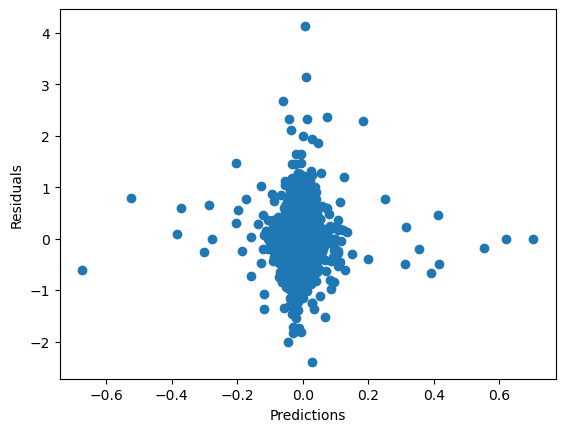

In [19]:
plt.scatter(res['Predictions'], res['Residuals'])
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

In [20]:
iv_Y = input_table['Inventory Turnover']
iv_X = input_table[['Constant','Current Ratio','Quick Ratio', 'Debt Asset Ratio']]
model_iv = sm.OLS(iv_Y,iv_X).fit()
print(model_iv.summary())

                            OLS Regression Results                            
Dep. Variable:     Inventory Turnover   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     258.4
Date:                Tue, 07 Oct 2025   Prob (F-statistic):          5.04e-138
Time:                        20:07:14   Log-Likelihood:                -8212.4
No. Observations:                1696   AIC:                         1.643e+04
Df Residuals:                    1692   BIC:                         1.645e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Constant            46.4258      1.434  

In [23]:
# output from first stage of 2SLS will become input for second part
endog_pred= model_iv.predict(iv_X)
input_table['Endogenous Param'] = endog_pred

In [24]:
Y_sls = input_table['Stock Change']
X_sls = input_table[['Constant', 'Endogenous Param', 'Operating Profit', 'Interaction Effect']]
sls_model = sm.OLS(Y_sls, X_sls).fit()
print(sls_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Stock Change   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     8.530
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           1.27e-05
Time:                        20:11:38   Log-Likelihood:                -1186.5
No. Observations:                1696   AIC:                             2381.
Df Residuals:                    1692   BIC:                             2403.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Constant              -0.0176      0

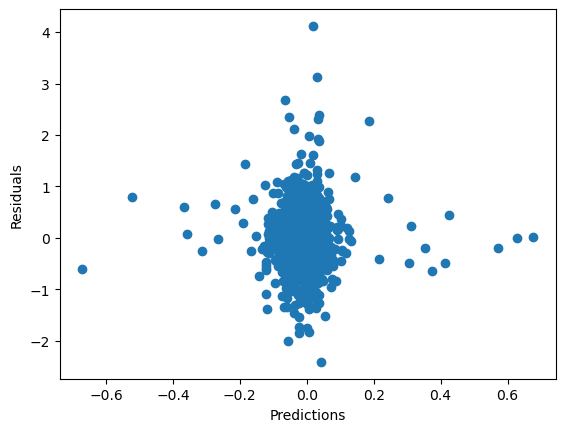

In [25]:
sls_pred = sls_model.predict(X_sls)
residuals = pd.DataFrame([Y_sls, sls_pred,(Y_sls - sls_pred)]).T
residuals.columns = ['Y','Predictions','Residuals']

plt.scatter(residuals['Predictions'], residuals['Residuals'])
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

In [27]:
# Generalized method of moments
y_vals = np.array(input_table['Stock Change'])
x_vals = np.array(input_table[['Inventory Turnover', 'Operating Profit', 'Interaction Effect']])
iv_vals = np.array(input_table[['Current Ratio', 'Quick Ratio', 'Debt Asset Ratio']])

In [28]:
# defining iterative algorithm but there is a function in statsmodels
class gmm(GMM):
    def momcond(self, params):
        p0, p1, p2, p3 = params
        endog = self.endog
        exog = self.exog
        inst = self.instrument   

        error0 = endog - p0 - p1 * exog[:,0] - p2 * exog[:,1] - p3 * exog[:,2]
        error1 = (endog - p0 - p1 * exog[:,0] - p2 * exog[:,1] - p3 * exog[:,2]) * exog[:,1]
        error2 = (endog - p0 - p1 * exog[:,0] - p2 * exog[:,1] - p3 * exog[:,2]) * exog[:,2]
        error3 = (endog - p0 - p1 * exog[:,0] - p2 * exog[:,1] - p3 * exog[:,2]) * inst[:,0] 
        error4 = (endog - p0 - p1 * exog[:,0] - p2 * exog[:,1] - p3 * exog[:,2]) * inst[:,1] 
        error5 = (endog - p0 - p1 * exog[:,0] - p2 * exog[:,1] - p3 * exog[:,2]) * inst[:,2] 

        g = np.column_stack((error0, error1, error2, error3, error4, error5))
        return g


beta0 = np.array([0.1, 0.1, 0.1, 0.1])
res = gmm(endog = y_vals, exog = x_vals, instrument = iv_vals, k_moms=6, k_params=4).fit(beta0)

res.summary()


Optimization terminated successfully.
         Current function value: 0.000046
         Iterations: 8
         Function evaluations: 12
         Gradient evaluations: 12
Optimization terminated successfully.
         Current function value: 0.000373
         Iterations: 7
         Function evaluations: 13
         Gradient evaluations: 13
Optimization terminated successfully.
         Current function value: 0.000372
         Iterations: 5
         Function evaluations: 9
         Gradient evaluations: 9
Optimization terminated successfully.
         Current function value: 0.000372
         Iterations: 5
         Function evaluations: 11
         Gradient evaluations: 11
Optimization terminated successfully.
         Current function value: 0.000372
         Iterations: 0
         Function evaluations: 1
         Gradient evaluations: 1


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 gmm Results                                  
==============================================================================
Dep. Variable:                      y   Hansen J:                       0.6317
Model:                            gmm   Prob (Hansen J):                 0.729
Method:                           GMM                                         
Date:                Tue, 07 Oct 2025                                         
Time:                        20:18:25                                         
No. Observations:                1696                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p 0           -0.0200      0.021     -0.964      0.335      -0.061       0.021
p 1            0.0011      0.001      1.843      0.065   -6.89e-05       0.002
p 2           -0.1071      0.032     -3.370      0.001      -0.169      -0.045
p 3            0.0011      0.000      2.760      0.006       0.000       0.002
==============================================================================
"""